# the used dataset is https://www.kaggle.com/datasets/puneet6060/intel-image-classification

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

In [2]:
train_data = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(150, 150),
    batch_size=32
)

val_data = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(150, 150),
    batch_size=32
)
test_data = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test",
    image_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


2026-08-17 18:48:05.774753: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.


In [3]:
class_names = train_data.class_names
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [4]:
for images, labels in train_data.take(1):
    print(images.shape)
    print(labels.shape)

(32, 150, 150, 3)
(32,)


In [5]:
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
val_data = val_data.map( lambda x, y: (normalization_layer(x), y))
test_data = test_data.map(lambda x, y: (normalization_layer(x), y))

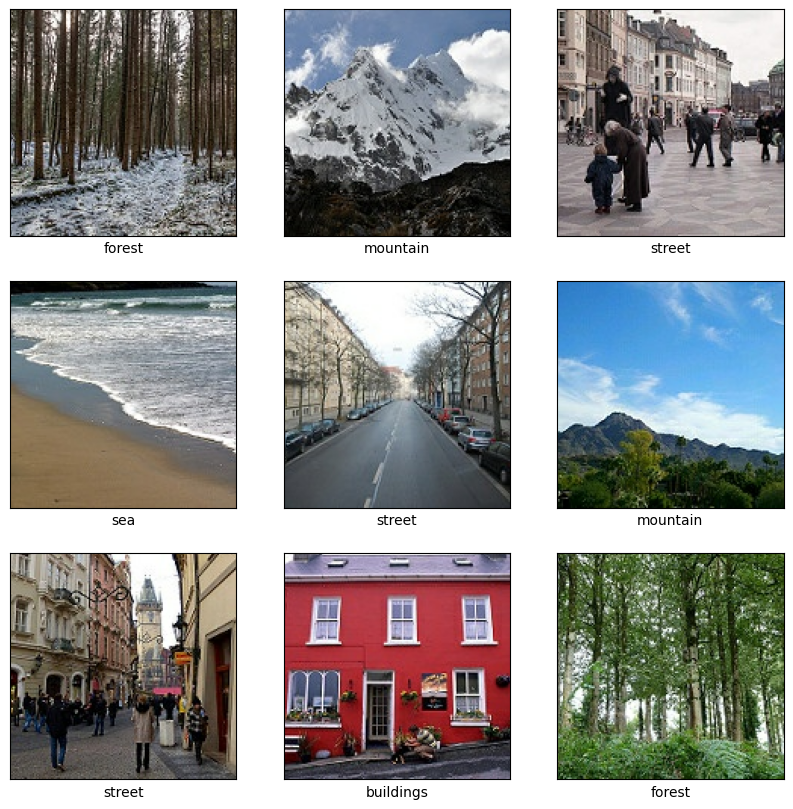

In [6]:
plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.xlabel(class_names[labels[i]])
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

plt.show()

In [7]:
model = models.Sequential()

model.add(
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(150, 150, 3)
    )
)

model.add(layers.MaxPooling2D((2, 2)))

model.add(
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    )
)

model.add(layers.MaxPooling2D((2, 2)))

model.add(
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.add(layers.Flatten())

model.add(
    layers.Dense(
        64,
        activation='relu'
    )
)
model.add(
    layers.Dropout(
        0.3
    )
)
model.add(
    layers.Dense(
        6,
        activation='softmax'
    )
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     4,735,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,791,750 (18.28 MB)

 Trainable params: 4,791,750 (18.28 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 169s 477ms/step - accuracy: 0.5429 - loss: 1.1507 - val_accuracy: 0.6761 - val_loss: 0.8535
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 157s 446ms/step - accuracy: 0.6768 - loss: 0.8574 - val_accuracy: 0.6507 - val_loss: 0.9712
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 154s 438ms/step - accuracy: 0.7310 - loss: 0.7371 - val_accuracy: 0.7762 - val_loss: 0.6566
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 149s 426ms/step - accuracy: 0.7799 - loss: 0.5961 - val_accuracy: 0.7798 - val_loss: 0.6445
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 160s 455ms/step - accuracy: 0.8277 - loss: 0.4772 - val_accuracy: 0.7986 - val_loss: 0.6362


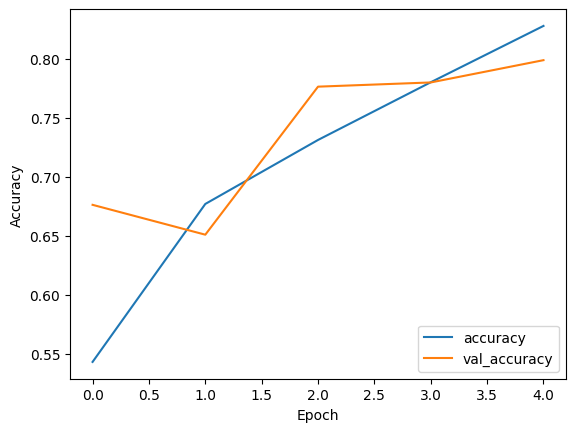

In [13]:
plt.plot(
    history.history['accuracy'],
    label='accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='val_accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

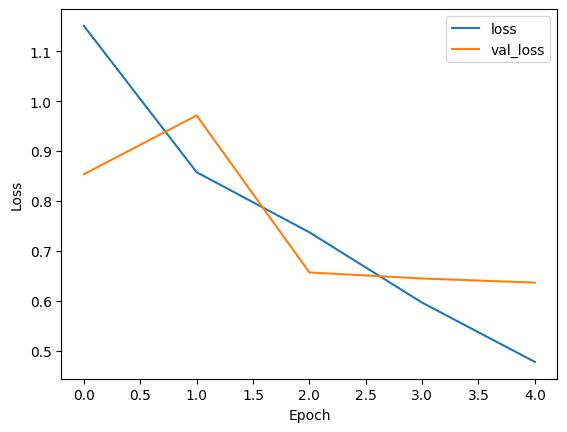

In [14]:
plt.plot(
    history.history['loss'],
    label='loss'
)

plt.plot(
    history.history['val_loss'],
    label='val_loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [15]:
test_loss, test_acc = model.evaluate(
    test_data,
    verbose=2
)

94/94 - 11s - 121ms/step - accuracy: 0.7943 - loss: 0.6413


In [16]:
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

Test Accuracy: 0.7943333387374878
Test Loss: 0.6412858366966248
